# MotorPH Product Distribution by Category
## Milestone 2 Draft — Data Analytics Fundamentals
**Prepared by:** Rowell Verdejo

This draft uses the cleaned MotorPH product list from Milestone 1 to compare the number of products in each Product Type category. Each row represents a listed product. Counts therefore describe the product line, rather than physical stock quantities or sales.
The draft contains one chart, a category summary, data checks, and an interpretation. No quarterly period is assigned because the dataset does not establish a Q3 2025 inventory snapshot.

## 1. Load the cleaned dataset

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

product_list = pd.read_csv("cleaned_data/MotorPH_Products_List_2025_cleaned.csv")
print(f"Rows: {len(product_list)} | Columns: {len(product_list.columns)}")
print(product_list.to_string())

Rows: 50 | Columns: 11
    Product ID Number         Product Name    Product Brand   Product Type Engine Configuration  Cooling System  Displacement (cc) Transmission  Date of Manufacturing  Date of Acquisition  Unit Price
0                   1              CBR500R            Honda          Sport        Parallel-twin   liquid-cooled                471      6-speed                   2021                 2023      389000
1                   2                MT-15           Yamaha     Naked bike      Single cylinder   liquid-cooled                155      6-speed                   2022                 2023      178000
2                   3            Ninja 400         Kawasaki          Sport        Parallel-twin   liquid-cooled                399      6-speed                   2023                 2024      340000
3                   4       Raider R150 Fi           Suzuki      Underbone      Single cylinder   liquid-cooled                150      6-speed                   2020           

## 2. Summarize products by category
Count product records in each category by using `value_counts()`. Add sorting in descending order for product_type_counts, and show percentages for each category's share of all listed products.


In [31]:
product_type_counts = product_list["Product Type"].value_counts().sort_index().sort_values(ascending=False, kind="stable")

total_products = len(product_list)
total_categories = len(product_type_counts)

category_summary = product_type_counts.rename("Number of Products").to_frame()
category_summary["Share (%)"] = category_summary["Number of Products"] / total_products * 100

print(f"Total categories: {total_categories}")
print(f"Total Products: {total_products}")
print(category_summary.to_string())

Total categories: 17
Total Products: 50
               Number of Products  Share (%)
Product Type                                
Scooter                        12       24.0
Naked bike                      7       14.0
Adventure                       4        8.0
Cruiser                         4        8.0
Sport                           4        8.0
Dual-sport                      3        6.0
Underbone                       3        6.0
Cafe racer                      2        4.0
Commuter                        2        4.0
Heritage                        2        4.0
Classic                         1        2.0
Retro                           1        2.0
Scrambler                       1        2.0
Sport touring                   1        2.0
Standard                        1        2.0
Street                          1        2.0
Touring                         1        2.0


## 4. Data Visualization
I used a horizontal bar chart because it compares discrete categories on a common count scale and leaves enough space for long category names. Adding percentage labels to each bar also make it easy to read.

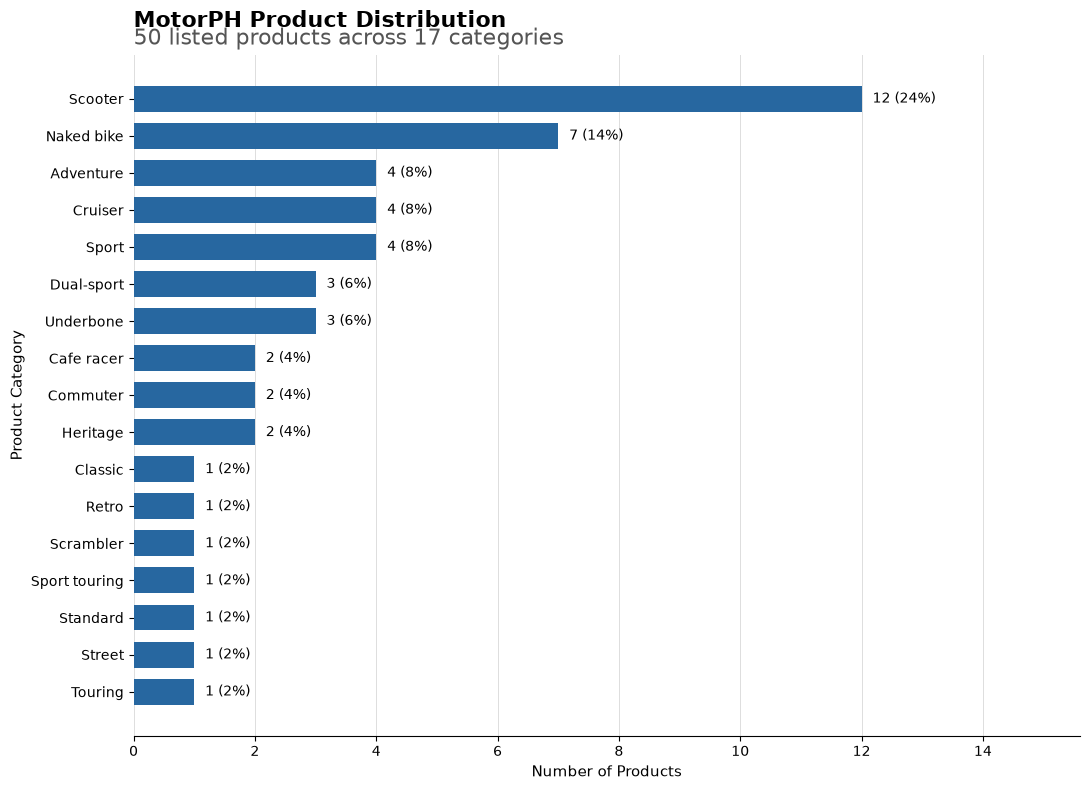

In [33]:
figure, axis = plt.subplots(figsize=(11, 8))

bars = axis.barh(
    product_type_counts.index,
    product_type_counts.values,
    color = "#2767A0",
    height = 0.7
)

axis.invert_yaxis()

axis.set_title(
    "MotorPH Product Distribution",
    loc = "left", fontsize = 16, fontweight = "bold", pad = 20
)

axis.text(0, 1.015, f"{total_products} listed products across {total_categories} categories", transform = axis.transAxes, fontsize = 16, color = "#555555")

axis.set_xlabel("Number of Products", fontsize = 11)
axis.set_ylabel("Product Category", fontsize = 11)
axis.xaxis.set_major_locator(MaxNLocator(integer=True))
axis.set_xlim(0, product_type_counts.max() * 1.3)
axis.set_axisbelow(True)
axis.grid(axis = "x", color = "#DDDDDD", linewidth = 0.7)
axis.tick_params(axis = "both", labelsize = 10)

for bar, count in zip(bars, product_type_counts.values):
    share = count / total_products * 100
    axis.text(
        bar.get_width() + 0.18,
        bar.get_y() + bar.get_height() / 2,
        f"{count} ({share:.0f}%)",
        va = "center",
        fontsize = 10
    )

for spine in ("top", "right", "left"):
    axis.spines[spine].set_visible(False)

figure.tight_layout()
figure.savefig("assets/MotorPH_Product_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Explanation and insights

The chart shows **50 listed products distributed across 17 categories**. Scooters has the largest share with 12 products (24%), followed by Naked bikes with 7 products (14%). These two categories account for 38% of the product list.

Adventure, Cruiser, and Sport each contain **4 products (8%)**. Dual-sport and Underbone each have **3 products (6%)**. while Cafe racer, Commuter, and Heritage each have **2 products (4%)**. The remaining seven categories contain **1 product (2%) each**. The comparisons show that MotorPH offers products across many categories, with more listed options in Scooter and Naked bike.

This can help MotorPH review how its product line is represented across cateogries. For example, the smaller categories could be examined alongside sales and customer preferences when considering additional product options. The counts alone does not establish customer demand, profitability, or available stock because the dataset doesn't contain sales totals or stock quantities. This chart can be combined with price comparisons by category to examine both the number of product options and its price ranges.

## 6. Process Workflow

**CSV loading** -> **Category collection** -> **Data visualization using matplotlib**.